# Customer Churn Deep Dive & Retention Action Plan

**Goal:** Understand why customers are churning, quantify the business impact, and produce a data-backed retention action plan.

**Dataset:** Synthetic customer churn dataset (2,000 customers), modeled on realistic telecom/subscription churn patterns, with intentional data-quality issues (missing values, duplicates, outliers) to reflect real-world conditions.

## 1. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/customer_churn_data.csv')
print("Raw data shape:", df.shape)
df.head()

Raw data shape: (2015, 13)


,CustomerID,Gender,Age,Tenure,SubscriptionType,ContractType,MonthlyCharges,TotalCharges,PaymentMethod,LoginFrequency,SupportTickets,LastActiveDate,Churn
0,CUST101577,Female,64,55,Premium,Month-to-month,110.04,6067.58,E-check,15,1.0,2026-06-22,No
1,CUST100140,Female,74,19,Basic,Two year,20.50,376.18,E-check,17,1.0,2026-07-01,No
2,CUST100110,Female,61,60,Basic,Month-to-month,19.40,1168.89,E-check,9,1.0,2026-05-22,Yes
3,CUST100259,Male,33,62,Basic,Month-to-month,26.72,1671.46,Bank transfer,11,0.0,2026-07-31,No
4,CUST101391,Female,27,61,Basic,One year,34.24,2064.51,Credit card,10,0.0,2026-05-19,No


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        2015 non-null   str    
 1   Gender            2015 non-null   str    
 2   Age               2015 non-null   int64  
 3   Tenure            2015 non-null   int64  
 4   SubscriptionType  2015 non-null   str    
 5   ContractType      2015 non-null   str    
 6   MonthlyCharges    2015 non-null   float64
 7   TotalCharges      2001 non-null   float64
 8   PaymentMethod     1975 non-null   str    
 9   LoginFrequency    2015 non-null   int64  
 10  SupportTickets    1985 non-null   float64
 11  LastActiveDate    2015 non-null   str    
 12  Churn             2015 non-null   str    
dtypes: float64(3), int64(3), str(7)
memory usage: 204.8 KB


In [3]:
df.isnull().sum()

CustomerID           0
Gender               0
Age                  0
Tenure               0
SubscriptionType     0
ContractType         0
MonthlyCharges       0
TotalCharges        14
PaymentMethod       40
LoginFrequency       0
SupportTickets      30
LastActiveDate       0
Churn                0
dtype: int64

## 2. Data Cleaning

Each missing/dirty value is handled based on its likely cause, not a blanket rule:

- **TotalCharges** (14 missing): only missing for brand-new customers (0 tenure) who haven't been billed yet -> fill with 0
- **PaymentMethod** (40 missing): appears to be random data entry gaps -> label as `"Unknown"` rather than guessing
- **SupportTickets** (30 missing): most plausibly means no ticket was ever logged -> fill with 0
- **Gender**: inconsistent capitalization (`FEMALE` vs `Female`) -> standardized
- **Duplicates**: 15 exact duplicate rows -> removed
- **Age outliers**: a few impossible values (0, -5, 130, 150) -> replaced with the median age

In [4]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['PaymentMethod'] = df['PaymentMethod'].fillna('Unknown')
df['SupportTickets'] = df['SupportTickets'].fillna(0)
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df = df.drop_duplicates()

median_age = df['Age'].median()
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = median_age

print("Cleaned data shape:", df.shape)
df.isnull().sum()

Cleaned data shape: (2000, 13)


CustomerID          0
Gender              0
Age                 0
Tenure              0
SubscriptionType    0
ContractType        0
MonthlyCharges      0
TotalCharges        0
PaymentMethod       0
LoginFrequency      0
SupportTickets      0
LastActiveDate      0
Churn               0
dtype: int64

In [5]:
df.to_csv('../data/cleaned/customer_churn_cleaned.csv', index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


## 3. Exploratory Data Analysis

### Q1: What is the overall churn rate?

Churn
No     75.25
Yes    24.75
Name: proportion, dtype: float64


C:\Users\panda\AppData\Local\Temp\ipykernel_3616\2597270331.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


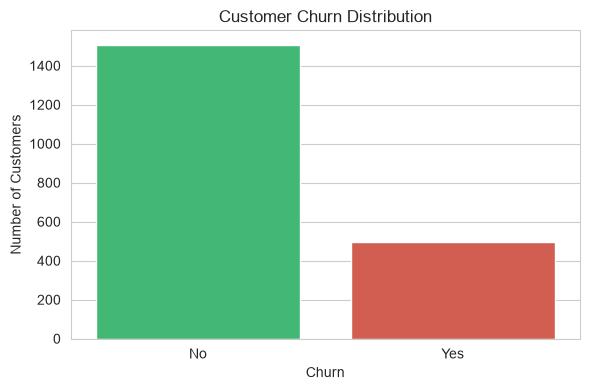

In [6]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', dpi=150)
plt.show()

**Finding:** Roughly 1 in 4 customers (~25%) have churned — a substantial share of the customer base at risk.

### Q2: Does contract type affect churn?

Churn                  No        Yes
ContractType                        
Month-to-month  66.580087  33.419913
One year        88.105727  11.894273
Two year        85.933504  14.066496


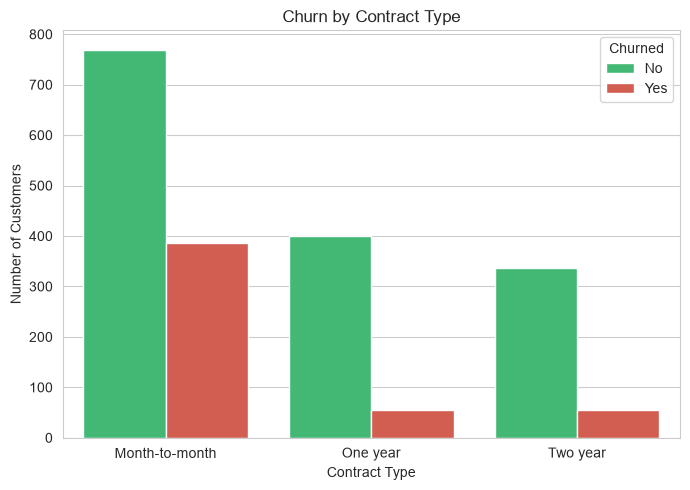

In [7]:
contract_churn = df.groupby('ContractType')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='ContractType', hue='Churn',
              order=['Month-to-month', 'One year', 'Two year'],
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned')
plt.tight_layout()
plt.savefig('../images/02_churn_by_contract.png', dpi=150)
plt.show()

**Finding:** Customers on month-to-month contracts show a substantially higher churn rate than those on one-year or two-year contracts. This is the **strongest single factor** found in this analysis.

**Important caveat:** this is a correlation observed in the data, not proof that contract type directly causes churn — customers who are already less committed may simply prefer shorter contracts.

### Q3: Does tenure affect churn?

Churn
No     37.004651
Yes    33.759596
Name: Tenure, dtype: float64


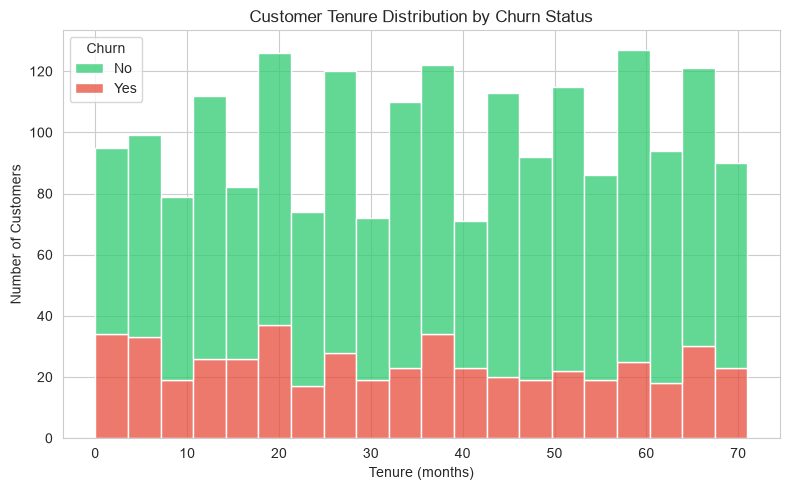

In [8]:
avg_tenure_churn = df.groupby('Churn')['Tenure'].mean()
print(avg_tenure_churn)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack',
             palette=['#2ecc71', '#e74c3c'], bins=20)
plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../images/03_tenure_distribution.png', dpi=150)
plt.show()

**Finding:** Churned customers have a slightly lower average tenure (~34 months) than retained customers (~37 months), but the difference is modest. Tenure alone is a **weak** predictor of churn here.

### Q4: Does usage (login frequency) relate to churn?

Churn
No     12.196013
Yes    11.713131
Name: LoginFrequency, dtype: float64


C:\Users\panda\AppData\Local\Temp\ipykernel_3616\724397995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='LoginFrequency', palette=['#2ecc71', '#e74c3c'])


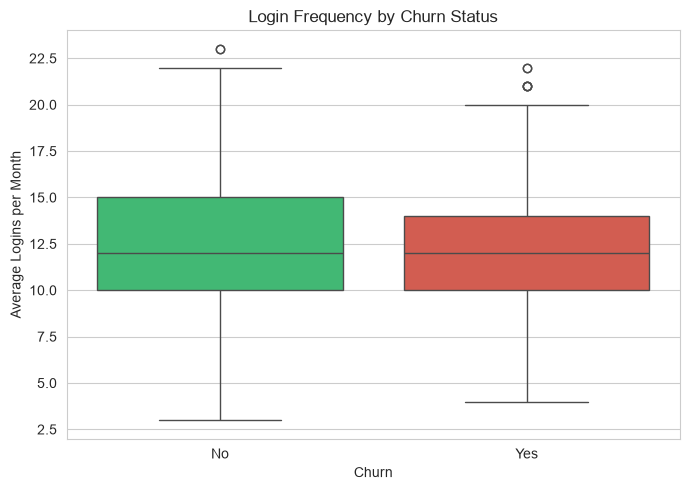

In [9]:
avg_login_churn = df.groupby('Churn')['LoginFrequency'].mean()
print(avg_login_churn)

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='LoginFrequency', palette=['#2ecc71', '#e74c3c'])
plt.title('Login Frequency by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Logins per Month')
plt.tight_layout()
plt.savefig('../images/04_login_frequency.png', dpi=150)
plt.show()

**Finding:** Login frequency shows almost no difference between churned and retained customers. **Negligible** relationship in this dataset.

### Q5: Do support tickets relate to churn?

Churn
No     1.209302
Yes    1.341414
Name: SupportTickets, dtype: float64

Churn rate for customers with 3+ tickets:
Churn
No     70.0
Yes    30.0
Name: proportion, dtype: float64


C:\Users\panda\AppData\Local\Temp\ipykernel_3616\2665224334.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='SupportTickets', palette=['#2ecc71', '#e74c3c'])


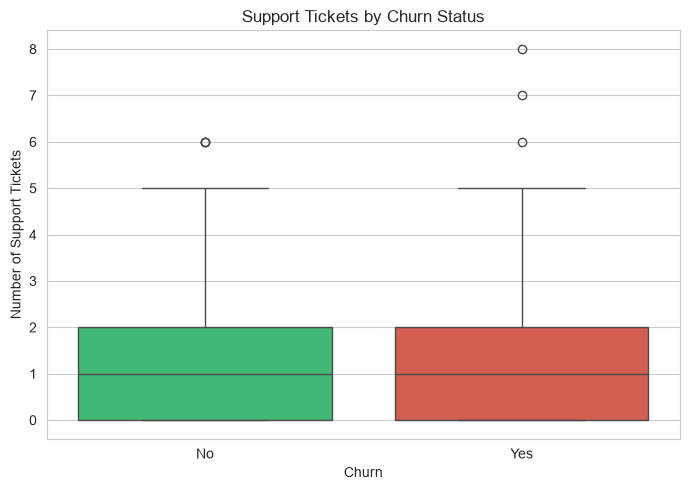

In [10]:
avg_tickets_churn = df.groupby('Churn')['SupportTickets'].mean()
print(avg_tickets_churn)

high_tickets = df[df['SupportTickets'] >= 3]
churn_rate_high_tickets = high_tickets['Churn'].value_counts(normalize=True) * 100
print("\nChurn rate for customers with 3+ tickets:")
print(churn_rate_high_tickets)

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='SupportTickets', palette=['#2ecc71', '#e74c3c'])
plt.title('Support Tickets by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Number of Support Tickets')
plt.tight_layout()
plt.savefig('../images/05_support_tickets.png', dpi=150)
plt.show()

**Finding:** Customers with 3+ support tickets churn at a noticeably higher rate than the overall baseline. A **moderate**, real risk factor tied to service friction.

### Q6: Which subscription type has the highest churn?

Churn                    No        Yes
SubscriptionType                      
Basic             76.376989  23.623011
Premium           73.299748  26.700252
Standard          75.063613  24.936387


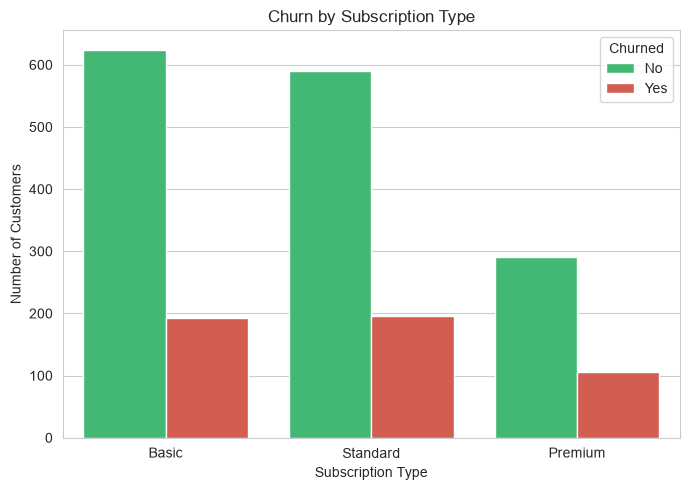

In [11]:
subscription_churn = df.groupby('SubscriptionType')['Churn'].value_counts(normalize=True).unstack() * 100
print(subscription_churn)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='SubscriptionType', hue='Churn',
              order=['Basic', 'Standard', 'Premium'],
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned')
plt.tight_layout()
plt.savefig('../images/06_churn_by_subscription.png', dpi=150)
plt.show()

**Finding:** Churn rates are similar across all subscription tiers, close to the overall baseline. **Weak** relationship — subscription tier alone doesn't drive churn.

### Q7: How much revenue is at risk?

In [12]:
total_monthly_revenue = df['MonthlyCharges'].sum()
churned_monthly_revenue = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
revenue_at_risk_pct = (churned_monthly_revenue / total_monthly_revenue) * 100
annual_revenue_lost = churned_monthly_revenue * 12

print(f"Total Monthly Revenue: ${total_monthly_revenue:,.2f}")
print(f"Monthly Revenue Lost to Churn: ${churned_monthly_revenue:,.2f}")
print(f"Percentage of Revenue at Risk: {revenue_at_risk_pct:.1f}%")
print(f"Estimated Annual Revenue Lost: ${annual_revenue_lost:,.2f}")

Total Monthly Revenue: $100,015.82
Monthly Revenue Lost to Churn: $25,176.55
Percentage of Revenue at Risk: 25.2%
Estimated Annual Revenue Lost: $302,118.60


**Finding:** Churned customers represent ~25% of total monthly recurring revenue (~$25K/month), projecting to roughly **$300K in annual lost revenue** if the pattern continues. This reframes churn as a direct revenue problem, not just a customer-count problem.

## 4. Root Cause Analysis — Compounding Risk Factors

Single-variable analysis can miss the full picture. Here we test whether risk factors **compound** — i.e., whether customers with multiple risk factors churn even more than any single factor alone would suggest.

In [13]:
# High-risk segment: month-to-month contract AND 3+ support tickets
high_risk = df[(df['ContractType'] == 'Month-to-month') & (df['SupportTickets'] >= 3)]
churn_rate_high_risk = high_risk['Churn'].value_counts(normalize=True) * 100
print(f"High-Risk Segment (Month-to-month + 3+ tickets)")
print(f"Segment size: {len(high_risk)} customers")
print(churn_rate_high_risk)

High-Risk Segment (Month-to-month + 3+ tickets)
Segment size: 146 customers
Churn
No     59.589041
Yes    40.410959
Name: proportion, dtype: float64


In [14]:
# Low-risk segment: annual contract AND fewer than 3 tickets
low_risk = df[(df['ContractType'] != 'Month-to-month') & (df['SupportTickets'] < 3)]
churn_rate_low_risk = low_risk['Churn'].value_counts(normalize=True) * 100
print(f"Low-Risk Segment (Annual contract + <3 tickets)")
print(f"Segment size: {len(low_risk)} customers")
print(churn_rate_low_risk)

Low-Risk Segment (Annual contract + <3 tickets)
Segment size: 721 customers
Churn
No     87.933426
Yes    12.066574
Name: proportion, dtype: float64


In [15]:
# High-value customers who churned (above-average monthly charges)
avg_charge = df['MonthlyCharges'].mean()
high_value_at_risk = df[(df['MonthlyCharges'] > avg_charge) & (df['Churn'] == 'Yes')]
print(f"High-Value Customers Who Churned: {len(high_value_at_risk)}")
print(f"Revenue lost from this segment: ${high_value_at_risk['MonthlyCharges'].sum():,.2f}/month")

High-Value Customers Who Churned: 242
Revenue lost from this segment: $17,580.72/month


**Root cause summary (verified results):**

- The **high-risk segment** (month-to-month + 3+ tickets, 146 customers) churns at **40.4%** — well above either factor alone (33% and 30% respectively). Clear evidence that risk factors **compound**.
- The **low-risk segment** (annual contract + <3 tickets, 721 customers) churns at just **12.1%** — less than half the overall baseline.
- That's a **3.3x difference in churn rate** between the highest-risk and lowest-risk segments — a very strong, actionable signal.
- **242 high-value customers** (above-average charges) churned, representing **$17,580/month** — about 70% of all revenue lost to churn comes from this above-average-value group.

**Caveat on causation:** these are strong, consistent correlational patterns across multiple cuts of the data, not a controlled experiment. We describe them as "customers with X show higher churn," not "X causes churn."

## 5. Customer Churn Playbook

| Segment / Risk Signal | Recommended Action |
|---|---|
| Month-to-month contract | Offer incentive to upgrade to annual contract (discount, added features) |
| 3+ support tickets | Flag for proactive support outreach / account review |
| Month-to-month + 3+ tickets (compounding risk) | Highest priority for retention team — combine contract offer with service recovery |
| High MonthlyCharges + churned | Priority win-back campaign — highest revenue impact per customer |
| New customers (low tenure) | Strengthen onboarding — early months carry disproportionate risk |

*Note: thresholds (e.g. "3+ tickets") are analytical assumptions based on where churn rate increases in this dataset, not fixed business rules — worth validating against real operational data.*

## 6. Key Takeaways

1. **Overall churn rate is ~25%**, representing ~$25K/month (~$300K/year) in recurring revenue at risk.
2. **Contract type is the strongest driver** — month-to-month customers churn far more than those on annual contracts.
3. **Support friction is a moderate but real driver** — customers with 3+ tickets churn at a meaningfully higher rate.
4. **Tenure, login frequency, and subscription type are weak/negligible drivers** on their own.
5. **Risk factors compound** — customers with both a short-term contract and high support friction are the highest-priority retention targets.
6. **Recommended focus:** contract conversion incentives + proactive support outreach for the compounding high-risk segment, with priority given to high-value accounts.